<a href="https://colab.research.google.com/github/kamalidoss/Transaction-Behavior-Analysis-in-Modern-Banking-Systems-using-Python/blob/main/Transaction_Behavior_Analysis_in_Modern_Banking_Systems_using_Python.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# *****Transaction Behavior Analysis in Modern Banking Systems using Python*****

*Transaction Behavior Analysis in Modern Banking Systems using Python focuses on analyzing banking transactions, digital payments, ATM usage, credit/debit card activity, and customer payment behavior. The project uses data cleaning, exploratory data analysis (EDA), statistical analysis, and visualizations to generate insights into digital banking trends and transaction patterns.*

# **Objectives**

*1. Maintain all banking transaction information (banks, ATMs, POS machines, credit cards, debit cards, UPI transactions, cash withdrawals) in one structured location.*

*2. Reduce data duplication and inconsistencies.*

*3. Monitor digital transactions, cash withdrawals, transaction value, and transaction volume over time.*

*4. Evaluate banking performance by bank category, digital channels, ATM usage, and transaction behavior.*

*5. Analyze customer preference toward digital payments vs cash transactions.*



# **Dataset Information**

***1. Source*** - Dataset collected from Indian Data Portal

***2. Link*** - https://indiadataportal.com/p/reserve-bank-of-india/r/rbi-bankwise_atm_pos-in-mn-bx

***2. Location*** - All India

***3. Year / Timeline*** : 2022 - 2025

***4. Domain*** - Economy / Banking

# Stage : 1 Problem Defenition, Dataset Selection and Buisness Understanding

In [1]:
#importing Libraries

import numpy as np
import pandas as pd

# Visualization Libraries
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

#Searching text patterns
import re

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

In [2]:
#Loading the Dataset

url=('https://raw.githubusercontent.com/kamalidoss/Transaction-Behavior-Analysis-in-Modern-Banking-Systems-using-Python/refs/heads/main/Dataset.csv')

df=pd.read_csv(url)

In [3]:
#To view the data:
df.head()

,id,date,bank_category,bank_name,atms_crms_onsite,atms_crms_offsite,pos,micro_atms,bharat_qr,upi_qr,...,dc_pay_trns_at_pos_vol,dc_pay_trns_at_pos_val,dc_pay_trns_online_vol,dc_pay_trns_online_val,dc_pay_trns_other_vol,dc_pay_trns_other_val,dc_cash_withdraw_atm_val,dc_cash_withdraw_atm_vol,dc_cash_withdraw_pos_val,dc_cash_withdraw_pos_vol
0,0,2022-03-01,Small Finance Banks,AU Small Finance Bank,407.0,3.0,0.0,321.0,0.0,487204.0,...,247593.0,602474.02,184714.0,573932.23,313.0,3426.59,890008.0,5.886433e+06,30.0,27.6
1,1,2022-03-01,Payment Banks,Airtel Payments Bank,0.0,0.0,0.0,0.0,0.0,3208634.0,...,0.0,0.00,213807.0,156600.18,0.0,0.00,0.0,0.000000e+00,0.0,0.0
2,2,2022-03-01,Foreign Banks,American Express,0.0,0.0,45455.0,0.0,0.0,0.0,...,0.0,0.00,0.0,0.00,0.0,0.00,0.0,0.000000e+00,0.0,0.0
3,3,2022-03-01,Private Sector Banks,Axis Bank,5748.0,11174.0,1010244.0,710.0,347644.0,36594577.0,...,12387481.0,27686318.61,6319140.0,18441049.67,26208.0,658186.04,22320612.0,1.379317e+08,0.0,0.0
4,4,2022-03-01,Private Sector Banks,Bandhan Bank,466.0,5.0,36339.0,0.0,0.0,0.0,...,592668.0,1405190.00,394699.0,918313.00,0.0,0.00,2658287.0,1.400377e+07,27811.0,27834.0


**Business Problem**

*Banks are rapidly moving toward digital payments such as UPI, QR payments, credit cards, and debit cards. The challenge is to analyze:*

*1. Which banking sector is leading in digital transformation?*

*2. How customers use cash vs digital transactions?*

*3. Which bank categories perform better?*

*4. How ATM usage is changing?*

*5. Which payment channels contribute most to transaction value?*

*6. Which banking sector generate the highest total digital transaction value?*

*7. How can banks be segmented into low, medium, and high transaction categories based on transaction behavior?*

*8. How have digital transactions and cash withdrawal patterns changed over time?*

**Expected Outcome**

*1. Identify banks that are leading in digital transformation and digital payment adoption.*

*2. Understand customer behavior toward cash withdrawals and digital transactions.*

*3. Compare the performance of different bank categories based on transaction activity and digital infrastructure.*

*4. Determine which payment channels contribute the highest transaction volume and transaction value.*

*5. Measure and identify banks with the highest total digital transaction value.*

*6. Classify banks based on their digital adoption levels using UPI and QR transaction activity.*

*7. Segment banks into low, medium, and high transaction groups for better business analysis and decision-making.*

*8. Identify a steady increase in digital transactions and transaction value over time*

**Dataset Features**

| Column Name              | Description                                                                        |
| ------------------------ | ---------------------------------------------------------------------------------- |
| id                       | Unique identification number for each record                                       |
| date                     | Date of transaction/report record                                                  |
| bank_category            | Category/type of bank (Small Finance Bank, Payment Bank, Foreign Bank, etc.)       |
| bank_name                | Name of the bank                                                                   |
| atms_crms_onsite         | Number of onsite ATMs and Cash Recycling Machines installed within bank premises   |
| atms_crms_offsite        | Number of offsite ATMs and Cash Recycling Machines installed outside bank premises |
| pos                      | Number of Point of Sale (POS) machines deployed by the bank                        |
| micro_atms               | Number of micro ATMs used for basic banking services                               |
| bharat_qr                | Number of Bharat QR codes issued/deployed                                          |
| upi_qr                   | Number of UPI QR codes deployed for digital payments                               |
| credit_cards             | Total number of credit cards issued by the bank                                    |
| debit_cards              | Total number of debit cards issued by the bank                                     |
| cc_pay_trns_at_pos_vol   | Volume/count of credit card transactions at POS terminals                          |
| cc_pay_trns_at_pos_val   | Total value of credit card transactions at POS terminals                           |
| cc_pay_trns_online_vol   | Volume/count of online credit card transactions                                    |
| cc_pay_trns_online_val   | Total value of online credit card transactions                                     |
| cc_pay_trns_other_vol    | Volume/count of other credit card transactions                                     |
| cc_pay_trns_other_val    | Total value of other credit card transactions                                      |
| cc_cash_withdraw_atm_val | Total value of cash withdrawn using credit cards at ATMs                           |
| cc_cash_withdraw_atm_vol | Volume/count of cash withdrawal transactions using credit cards at ATMs            |
| dc_pay_trns_at_pos_vol   | Volume/count of debit card transactions at POS terminals                           |
| dc_pay_trns_at_pos_val   | Total value of debit card transactions at POS terminals                            |
| dc_pay_trns_online_vol   | Volume/count of online debit card transactions                                     |
| dc_pay_trns_online_val   | Total value of online debit card transactions                                      |
| dc_pay_trns_other_vol    | Volume/count of other debit card transactions                                      |
| dc_pay_trns_other_val    | Total value of other debit card transactions                                       |
| dc_cash_withdraw_atm_val | Total value of cash withdrawn using debit cards at ATMs                            |
| dc_cash_withdraw_atm_vol | Volume/count of cash withdrawal transactions using debit cards at ATMs             |
| dc_cash_withdraw_pos_val | Total value of debit card cash withdrawals at POS terminals                        |
| dc_cash_withdraw_pos_vol | Volume/count of debit card cash withdrawals at POS terminals                       |


**Initial Exploratory Data Analysis (EDA)**

In [4]:
# Shape of dataset
df.shape

(2671, 30)

In [5]:
# Dataset Information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2671 entries, 0 to 2670
Data columns (total 30 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   id                        2671 non-null   int64  
 1   date                      2671 non-null   object 
 2   bank_category             2671 non-null   object 
 3   bank_name                 2671 non-null   object 
 4   atms_crms_onsite          2664 non-null   float64
 5   atms_crms_offsite         2655 non-null   float64
 6   pos                       2671 non-null   float64
 7   micro_atms                2671 non-null   float64
 8   bharat_qr                 2671 non-null   float64
 9   upi_qr                    2671 non-null   float64
 10  credit_cards              2671 non-null   float64
 11  debit_cards               2671 non-null   float64
 12  cc_pay_trns_at_pos_vol    2669 non-null   float64
 13  cc_pay_trns_at_pos_val    2669 non-null   float64
 14  cc_pay_t

In [6]:
# Statistical Summary
df.describe()

,id,atms_crms_onsite,atms_crms_offsite,pos,micro_atms,bharat_qr,upi_qr,credit_cards,debit_cards,cc_pay_trns_at_pos_vol,...,dc_pay_trns_at_pos_vol,dc_pay_trns_at_pos_val,dc_pay_trns_online_vol,dc_pay_trns_online_val,dc_pay_trns_other_vol,dc_pay_trns_other_val,dc_cash_withdraw_atm_val,dc_cash_withdraw_atm_vol,dc_cash_withdraw_pos_val,dc_cash_withdraw_pos_vol
count,2671.000000,2664.000000,2655.000000,2.671000e+03,2671.000000,2.671000e+03,2.671000e+03,2.671000e+03,2.671000e+03,2.669000e+03,...,2.671000e+03,2.671000e+03,2.671000e+03,2.671000e+03,2671.000000,2.671000e+03,2.671000e+03,2.671000e+03,2671.000000,2671.000000
mean,1335.000000,2028.725225,1473.012429,1.413899e+05,23205.326844,9.285328e+04,6.671178e+06,1.537410e+06,1.555674e+07,2.781815e+06,...,2.188121e+06,5.199525e+06,9.206808e+05,2.602492e+06,3539.369525,4.245622e+04,8.528873e+06,4.222635e+07,1823.195432,1822.704103
std,771.195609,4074.411961,5140.008633,4.303179e+05,73897.653634,2.952903e+05,4.352378e+07,4.222255e+06,3.523464e+07,9.020355e+06,...,6.008689e+06,1.382787e+07,2.668757e+06,6.994796e+06,30971.494770,2.455566e+05,2.338451e+07,1.185707e+08,8212.473137,8358.250105
min,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000
25%,667.500000,2.000000,0.000000,0.000000e+00,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,6.323550e+05,0.000000e+00,...,2.200050e+04,3.552932e+04,7.909000e+03,1.978267e+04,0.000000,0.000000e+00,9.423050e+04,3.583838e+05,0.000000,0.000000
50%,1335.000000,451.000000,38.000000,1.418000e+03,99.000000,0.000000e+00,4.123600e+04,1.161000e+04,3.764048e+06,2.590200e+04,...,2.753200e+05,6.292487e+05,1.090650e+05,2.751515e+05,0.000000,0.000000e+00,1.370925e+06,6.280297e+06,0.000000,0.000000
75%,2002.500000,1806.000000,647.000000,2.698000e+04,6686.000000,8.577500e+03,6.180955e+05,7.249470e+05,1.348254e+07,7.434080e+05,...,1.685629e+06,3.403230e+06,5.698790e+05,1.328164e+06,71.500000,6.832850e+02,6.302256e+06,3.045267e+07,18.000000,13.950000
max,2670.000000,28848.000000,40016.000000,3.314358e+06,520301.000000,2.372486e+06,5.461064e+08,2.528505e+07,2.795300e+08,9.348959e+07,...,6.138705e+07,1.301914e+08,3.351193e+07,5.455468e+07,616836.000000,4.278795e+06,2.065163e+08,1.006311e+09,83123.000000,131442.860000


In [7]:
# Column Names
df.columns

Index(['id', 'date', 'bank_category', 'bank_name', 'atms_crms_onsite',
       'atms_crms_offsite', 'pos', 'micro_atms', 'bharat_qr', 'upi_qr',
       'credit_cards', 'debit_cards', 'cc_pay_trns_at_pos_vol',
       'cc_pay_trns_at_pos_val', 'cc_pay_trns_online_vol',
       'cc_pay_trns_online_val', 'cc_pay_trns_other_vol',
       'cc_pay_trns_other_val', 'cc_cash_withdraw_atm_val',
       'cc_cash_withdraw_atm_vol', 'dc_pay_trns_at_pos_vol',
       'dc_pay_trns_at_pos_val', 'dc_pay_trns_online_vol',
       'dc_pay_trns_online_val', 'dc_pay_trns_other_vol',
       'dc_pay_trns_other_val', 'dc_cash_withdraw_atm_val',
       'dc_cash_withdraw_atm_vol', 'dc_cash_withdraw_pos_val',
       'dc_cash_withdraw_pos_vol'],
      dtype='object')

In [8]:
#View first 5 rows
df.head()

,id,date,bank_category,bank_name,atms_crms_onsite,atms_crms_offsite,pos,micro_atms,bharat_qr,upi_qr,...,dc_pay_trns_at_pos_vol,dc_pay_trns_at_pos_val,dc_pay_trns_online_vol,dc_pay_trns_online_val,dc_pay_trns_other_vol,dc_pay_trns_other_val,dc_cash_withdraw_atm_val,dc_cash_withdraw_atm_vol,dc_cash_withdraw_pos_val,dc_cash_withdraw_pos_vol
0,0,2022-03-01,Small Finance Banks,AU Small Finance Bank,407.0,3.0,0.0,321.0,0.0,487204.0,...,247593.0,602474.02,184714.0,573932.23,313.0,3426.59,890008.0,5.886433e+06,30.0,27.6
1,1,2022-03-01,Payment Banks,Airtel Payments Bank,0.0,0.0,0.0,0.0,0.0,3208634.0,...,0.0,0.00,213807.0,156600.18,0.0,0.00,0.0,0.000000e+00,0.0,0.0
2,2,2022-03-01,Foreign Banks,American Express,0.0,0.0,45455.0,0.0,0.0,0.0,...,0.0,0.00,0.0,0.00,0.0,0.00,0.0,0.000000e+00,0.0,0.0
3,3,2022-03-01,Private Sector Banks,Axis Bank,5748.0,11174.0,1010244.0,710.0,347644.0,36594577.0,...,12387481.0,27686318.61,6319140.0,18441049.67,26208.0,658186.04,22320612.0,1.379317e+08,0.0,0.0
4,4,2022-03-01,Private Sector Banks,Bandhan Bank,466.0,5.0,36339.0,0.0,0.0,0.0,...,592668.0,1405190.00,394699.0,918313.00,0.0,0.00,2658287.0,1.400377e+07,27811.0,27834.0


In [9]:
#View last 5 rows
df.tail()

,id,date,bank_category,bank_name,atms_crms_onsite,atms_crms_offsite,pos,micro_atms,bharat_qr,upi_qr,...,dc_pay_trns_at_pos_vol,dc_pay_trns_at_pos_val,dc_pay_trns_online_vol,dc_pay_trns_online_val,dc_pay_trns_other_vol,dc_pay_trns_other_val,dc_cash_withdraw_atm_val,dc_cash_withdraw_atm_vol,dc_cash_withdraw_pos_val,dc_cash_withdraw_pos_vol
2666,2666,2025-09-01,Public Sector Banks,Union Bank of India,7866.0,1196.0,53428.0,8059.0,369473.0,291785.0,...,3588891.0,8505983.90,908024.0,2442384.88,2150.0,8722.95,40386186.0,1.188093e+08,11.0,2.2
2667,2667,2025-09-01,Small Finance Banks,Unity Small Finance Bank,189.0,0.0,0.0,0.0,0.0,0.0,...,7717.0,23757.79,1070.0,5767.80,0.0,0.00,38324.0,1.881812e+05,0.0,0.0
2668,2668,2025-09-01,Small Finance Banks,Utkarsh Small Finance Bank,301.0,5.0,0.0,778.0,0.0,41236.0,...,18070.0,62342.98,3982.0,27133.72,1.0,0.50,154064.0,9.180436e+05,0.0,0.0
2669,2669,2025-09-01,Foreign Banks,Woori Bank,0.0,0.0,0.0,0.0,0.0,0.0,...,1752.0,6635.04,684.0,1921.88,0.0,0.00,575.0,4.816600e+03,0.0,0.0
2670,2670,2025-09-01,Private Sector Banks,Yes Bank,1188.0,128.0,100668.0,78109.0,115378.0,546106442.0,...,382411.0,1225136.79,116553.0,777696.70,21.0,256.75,1663845.0,9.965342e+06,0.0,0.0


In [10]:
#Check Null Values
df.isnull().sum()

,0
id,0
date,0
bank_category,0
bank_name,0
atms_crms_onsite,7
atms_crms_offsite,16
pos,0
micro_atms,0
bharat_qr,0
upi_qr,0


In [11]:
#Check Duplicate Records
df.duplicated().sum()

np.int64(0)

**Interpretation of Stage-1:**

The initial exploratory data analysis shows that the dataset contains 2671 rows and 30 columns, indicating a sufficiently large dataset for banking transaction analysis. The dataset includes information related to bank categories, ATM infrastructure, digital payment systems, credit/debit card transactions, and cash withdrawals.

Most columns contain numerical transaction-related data represented in float64 format, while categorical details such as bank_category, bank_name, and date are stored as object data types. The dataset is memory efficient and suitable for further analysis and visualization.

The null value analysis identified a small number of missing values in columns related to ATM infrastructure and credit card transactions, while the remaining columns contain complete records. No major data inconsistency issues were observed during the initial inspection.

The statistical summary indicates high variation in transaction values and banking infrastructure across different banks, suggesting the presence of diverse banking behaviors and transaction patterns. Overall, the dataset is well-structured and appropriate for performing data cleaning, statistical analysis, visualization, and banking transaction analytics.

# **Stage 2 – Data Cleaning and Pre-processing**

**1. Check Duplicate Records**

In [12]:
# Check duplicate rows

df.duplicated().sum()

np.int64(0)

**2. Check Missing Values**

In [13]:
# Find missing values

df.isnull().sum()

,0
id,0
date,0
bank_category,0
bank_name,0
atms_crms_onsite,7
atms_crms_offsite,16
pos,0
micro_atms,0
bharat_qr,0
upi_qr,0


**3. Handle Missing Values**

In [14]:
# Columns with missing values

columns_to_impute = [
    'atms_crms_onsite',
    'atms_crms_offsite',
    'cc_pay_trns_at_pos_vol',
    'cc_pay_trns_at_pos_val',
    'cc_pay_trns_online_vol',
    'cc_pay_trns_online_val',
    'cc_pay_trns_other_vol',
    'cc_pay_trns_other_val',
    'cc_cash_withdraw_atm_val',
    'cc_cash_withdraw_atm_vol'
]

In [15]:
# Hierarchical Imputation in Single Step

for col in columns_to_impute:

    df[col] = (
        df.groupby('bank_name')[col]
        .transform(lambda x: x.fillna(x.median()))
    )

    df[col] = (
        df.groupby('bank_category')[col]
        .transform(lambda x: x.fillna(x.median()))
    )

    df[col].fillna(df[col].median(), inplace=True)

In [16]:
# Recheck missing values

df.isnull().sum()

,0
id,0
date,0
bank_category,0
bank_name,0
atms_crms_onsite,0
atms_crms_offsite,0
pos,0
micro_atms,0
bharat_qr,0
upi_qr,0


**4. Convert Data Types**

In [17]:
# Convert date column into datetime format

df['date'] = pd.to_datetime(df['date'])

# Verify datatype

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2671 entries, 0 to 2670
Data columns (total 30 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   id                        2671 non-null   int64         
 1   date                      2671 non-null   datetime64[ns]
 2   bank_category             2671 non-null   object        
 3   bank_name                 2671 non-null   object        
 4   atms_crms_onsite          2671 non-null   float64       
 5   atms_crms_offsite         2671 non-null   float64       
 6   pos                       2671 non-null   float64       
 7   micro_atms                2671 non-null   float64       
 8   bharat_qr                 2671 non-null   float64       
 9   upi_qr                    2671 non-null   float64       
 10  credit_cards              2671 non-null   float64       
 11  debit_cards               2671 non-null   float64       
 12  cc_pay_trns_at_pos_v

**5. Rename Column Names**

In [18]:
# Rename columns in short readable format

df.rename(columns={

    'cc_pay_trns_at_pos_vol'   : 'cc_pos_vol',
    'cc_pay_trns_at_pos_val'   : 'cc_pos_val',

    'cc_pay_trns_online_vol'   : 'cc_online_vol',
    'cc_pay_trns_online_val'   : 'cc_online_val',

    'cc_pay_trns_other_vol'    : 'cc_other_vol',
    'cc_pay_trns_other_val'    : 'cc_other_val',

    'cc_cash_withdraw_atm_val' : 'cc_atm_cash_val',
    'cc_cash_withdraw_atm_vol' : 'cc_atm_cash_vol',

    'dc_pay_trns_at_pos_vol'   : 'dc_pos_vol',
    'dc_pay_trns_at_pos_val'   : 'dc_pos_val',

    'dc_pay_trns_online_vol'   : 'dc_online_vol',
    'dc_pay_trns_online_val'   : 'dc_online_val',

    'dc_pay_trns_other_vol'    : 'dc_other_vol',
    'dc_pay_trns_other_val'    : 'dc_other_val',

    'dc_cash_withdraw_atm_val' : 'dc_atm_cash_val',
    'dc_cash_withdraw_atm_vol' : 'dc_atm_cash_vol',

    'dc_cash_withdraw_pos_val' : 'dc_pos_cash_val',
    'dc_cash_withdraw_pos_vol' : 'dc_pos_cash_vol'

}, inplace=True)

In [19]:
# View updated column names

df.columns

Index(['id', 'date', 'bank_category', 'bank_name', 'atms_crms_onsite',
       'atms_crms_offsite', 'pos', 'micro_atms', 'bharat_qr', 'upi_qr',
       'credit_cards', 'debit_cards', 'cc_pos_vol', 'cc_pos_val',
       'cc_online_vol', 'cc_online_val', 'cc_other_vol', 'cc_other_val',
       'cc_atm_cash_val', 'cc_atm_cash_vol', 'dc_pos_vol', 'dc_pos_val',
       'dc_online_vol', 'dc_online_val', 'dc_other_vol', 'dc_other_val',
       'dc_atm_cash_val', 'dc_atm_cash_vol', 'dc_pos_cash_val',
       'dc_pos_cash_vol'],
      dtype='object')

**6. Check Outliers**

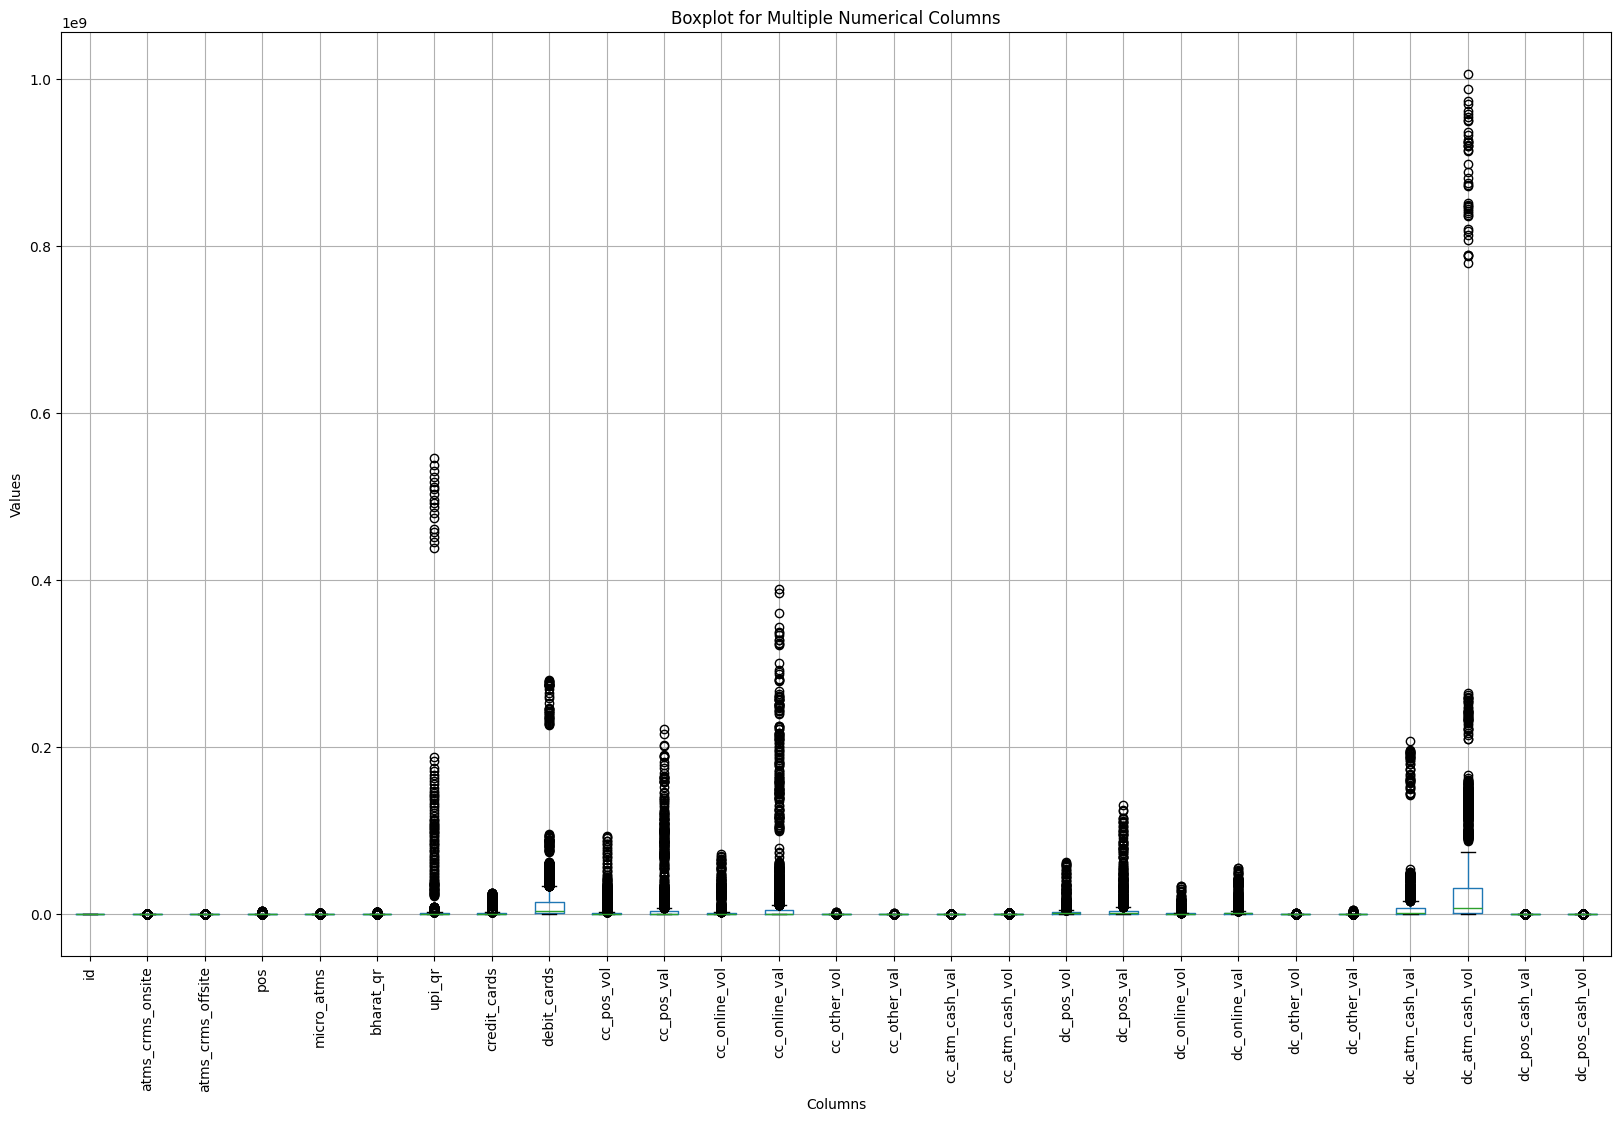

In [20]:
# Multiple Outlier Detection using Boxplots

plt.figure(figsize=(20,12))

# Select numerical columns
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

# Plot boxplots
df[num_cols].boxplot(rot=90)

plt.title("Boxplot for Multiple Numerical Columns")
plt.xlabel("Columns")
plt.ylabel("Values")

plt.show()

**7. Create New Features (Feature Engineering)**

In [21]:
# 1. Total Digital Transaction Value (Numerical)

df['total_digital_value'] = (
    df['cc_online_val'] +
    df['dc_online_val'] +
    df['cc_pos_val'] +
    df['dc_pos_val']
)

In [22]:
# 2. Cash Dependency Ratio (Numerical)

df['cash_dependency_ratio'] = (
    (df['dc_atm_cash_val'] + df['cc_atm_cash_val']) /
    (df['total_digital_value'] + 1)
)

In [23]:
# 3. Digital Adoption Level (Categorical)

df['digital_adoption_level'] = np.where(
    df['upi_qr'] > df['upi_qr'].median(),
    'High Digital Adoption',
    'Low Digital Adoption'
)

In [24]:
# 4. Bank Transaction Size (Categorical)

df['transaction_size'] = pd.cut(
    df['total_digital_value'],
    bins=[0, 1000000, 10000000, df['total_digital_value'].max()],
    labels=['Low', 'Medium', 'High']
)

In [25]:
#Final Check
df[['total_digital_value',
    'cash_dependency_ratio',
    'digital_adoption_level',
    'transaction_size']].head()

,total_digital_value,cash_dependency_ratio,digital_adoption_level,transaction_size
0,4.443490e+06,0.201308,High Digital Adoption,Medium
1,1.566002e+05,0.000000,High Digital Adoption,Low
2,3.277009e+07,0.000000,Low Digital Adoption,High
3,1.399924e+08,0.159768,High Digital Adoption,High
4,2.323503e+06,1.144085,Low Digital Adoption,Medium


**8. Final Dataset Information**

In [26]:
# Final dataset information

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2671 entries, 0 to 2670
Data columns (total 34 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   id                      2671 non-null   int64         
 1   date                    2671 non-null   datetime64[ns]
 2   bank_category           2671 non-null   object        
 3   bank_name               2671 non-null   object        
 4   atms_crms_onsite        2671 non-null   float64       
 5   atms_crms_offsite       2671 non-null   float64       
 6   pos                     2671 non-null   float64       
 7   micro_atms              2671 non-null   float64       
 8   bharat_qr               2671 non-null   float64       
 9   upi_qr                  2671 non-null   float64       
 10  credit_cards            2671 non-null   float64       
 11  debit_cards             2671 non-null   float64       
 12  cc_pos_vol              2671 non-null   float64 

**9. Final Statistical Summary**

In [27]:
# Final statistical summary

df.describe()

,id,date,atms_crms_onsite,atms_crms_offsite,pos,micro_atms,bharat_qr,upi_qr,credit_cards,debit_cards,...,dc_online_vol,dc_online_val,dc_other_vol,dc_other_val,dc_atm_cash_val,dc_atm_cash_vol,dc_pos_cash_val,dc_pos_cash_vol,total_digital_value,cash_dependency_ratio
count,2671.000000,2671,2671.000000,2671.000000,2.671000e+03,2671.000000,2.671000e+03,2.671000e+03,2.671000e+03,2.671000e+03,...,2.671000e+03,2.671000e+03,2671.000000,2.671000e+03,2.671000e+03,2.671000e+03,2671.000000,2671.000000,2.671000e+03,2671.000000
mean,1335.000000,2023-12-13 14:31:13.455634688,2023.523212,1464.191314,1.413899e+05,23205.326844,9.285328e+04,6.671178e+06,1.537410e+06,1.555674e+07,...,9.206808e+05,2.602492e+06,3539.369525,4.245622e+04,8.528873e+06,4.222635e+07,1823.195432,1822.704103,3.265540e+07,2.601392
min,0.000000,2022-03-01 00:00:00,0.000000,0.000000,0.000000e+00,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,0.000000e+00,0.000000e+00,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000e+00,0.000000
25%,667.500000,2023-02-01 00:00:00,2.000000,0.000000,0.000000e+00,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,6.323550e+05,...,7.909000e+03,1.978267e+04,0.000000,0.000000e+00,9.423050e+04,3.583838e+05,0.000000,0.000000,1.323584e+05,0.100348
50%,1335.000000,2024-01-01 00:00:00,449.000000,37.000000,1.418000e+03,99.000000,0.000000e+00,4.123600e+04,1.161000e+04,3.764048e+06,...,1.090650e+05,2.751515e+05,0.000000,0.000000e+00,1.370925e+06,6.280297e+06,0.000000,0.000000,2.459525e+06,0.907741
75%,2002.500000,2024-11-01 00:00:00,1799.500000,646.500000,2.698000e+04,6686.000000,8.577500e+03,6.180955e+05,7.249470e+05,1.348254e+07,...,5.698790e+05,1.328164e+06,71.500000,6.832850e+02,6.302256e+06,3.045267e+07,18.000000,13.950000,1.620412e+07,1.693448
max,2670.000000,2025-09-01 00:00:00,28848.000000,40016.000000,3.314358e+06,520301.000000,2.372486e+06,5.461064e+08,2.528505e+07,2.795300e+08,...,3.351193e+07,5.455468e+07,616836.000000,4.278795e+06,2.065163e+08,1.006311e+09,83123.000000,131442.860000,6.738575e+08,597.000000
std,771.195609,NaN,4070.336924,5125.844838,4.303179e+05,73897.653634,2.952903e+05,4.352378e+07,4.222255e+06,3.523464e+07,...,2.668757e+06,6.994796e+06,30971.494770,2.455566e+05,2.338451e+07,1.185707e+08,8212.473137,8358.250105,9.253163e+07,24.311864


***10. Interpretation of Stage-2:***

*In this stage, the dataset was successfully cleaned and transformed to improve data quality and analytical reliability. Duplicate records were checked and no records found.*

*Missing values identified in ATM and transaction-related columns were handled using hierarchical imputation techniques. The imputation process first considered bank-level median values, followed by bank-category-level medians, and finally overall dataset medians wherever necessary. This approach preserved the natural banking transaction behavior and reduced distortion in financial patterns.*

*Several lengthy column names were renamed into shorter and more readable formats to improve coding efficiency and interpretability. Data types were also verified and transformed where required to support accurate analysis and visualization.*

*Outlier analysis was performed using boxplots across multiple numerical columns. Significant outliers were observed in transaction and withdrawal-related variables, indicating that some banks process exceptionally high transaction volumes and values. These outliers were intentionally retained because they represent genuine customer banking transactions and real business activity. Removing them could lead to loss of important financial insights.*

*Additionally, new feature-engineered columns were created to strengthen business analysis. Numerical features such as total digital transaction value and cash dependency ratio helped measure digital banking performance and cash usage behavior. Categorical features such as digital adoption level and transaction size enabled segmentation of banks based on transaction patterns and digital maturity.*

*Overall, Stage 2 significantly improved the dataset’s structure, consistency, and analytical value, making it suitable for advanced statistical analysis, visualizations, and business insight generation.*

# **Stage 3 - Statistical analysis & Visualizations**

**1. Measure of Central Tendency**

*Mean, Median and Mode*

In [28]:
# Measure of Central Tendency

cols = [
    'upi_qr',
    'cc_online_val',
    'dc_online_val',
    'dc_atm_cash_val',
    'total_digital_value',
    'cash_dependency_ratio'
]

Summary_Table = pd.DataFrame({

    'Mean'   : df[cols].mean(),
    'Median' : df[cols].median(),
    'Mode'   : df[cols].mode().iloc[0]

})

# Round values
Summary_Table = Summary_Table.round(2)

# Display Table
print("Measure of Central Tendency:\n")
Summary_Table

Measure of Central Tendency:



,Mean,Median,Mode
upi_qr,6671177.88,41236.00,0.0
cc_online_val,15687199.76,64623.97,0.0
dc_online_val,2602491.93,275151.54,0.0
dc_atm_cash_val,8528872.66,1370925.00,0.0
total_digital_value,32655399.08,2459525.01,0.0
cash_dependency_ratio,2.60,0.91,0.0


**1.a. Chart for Measure of Central Tendency**

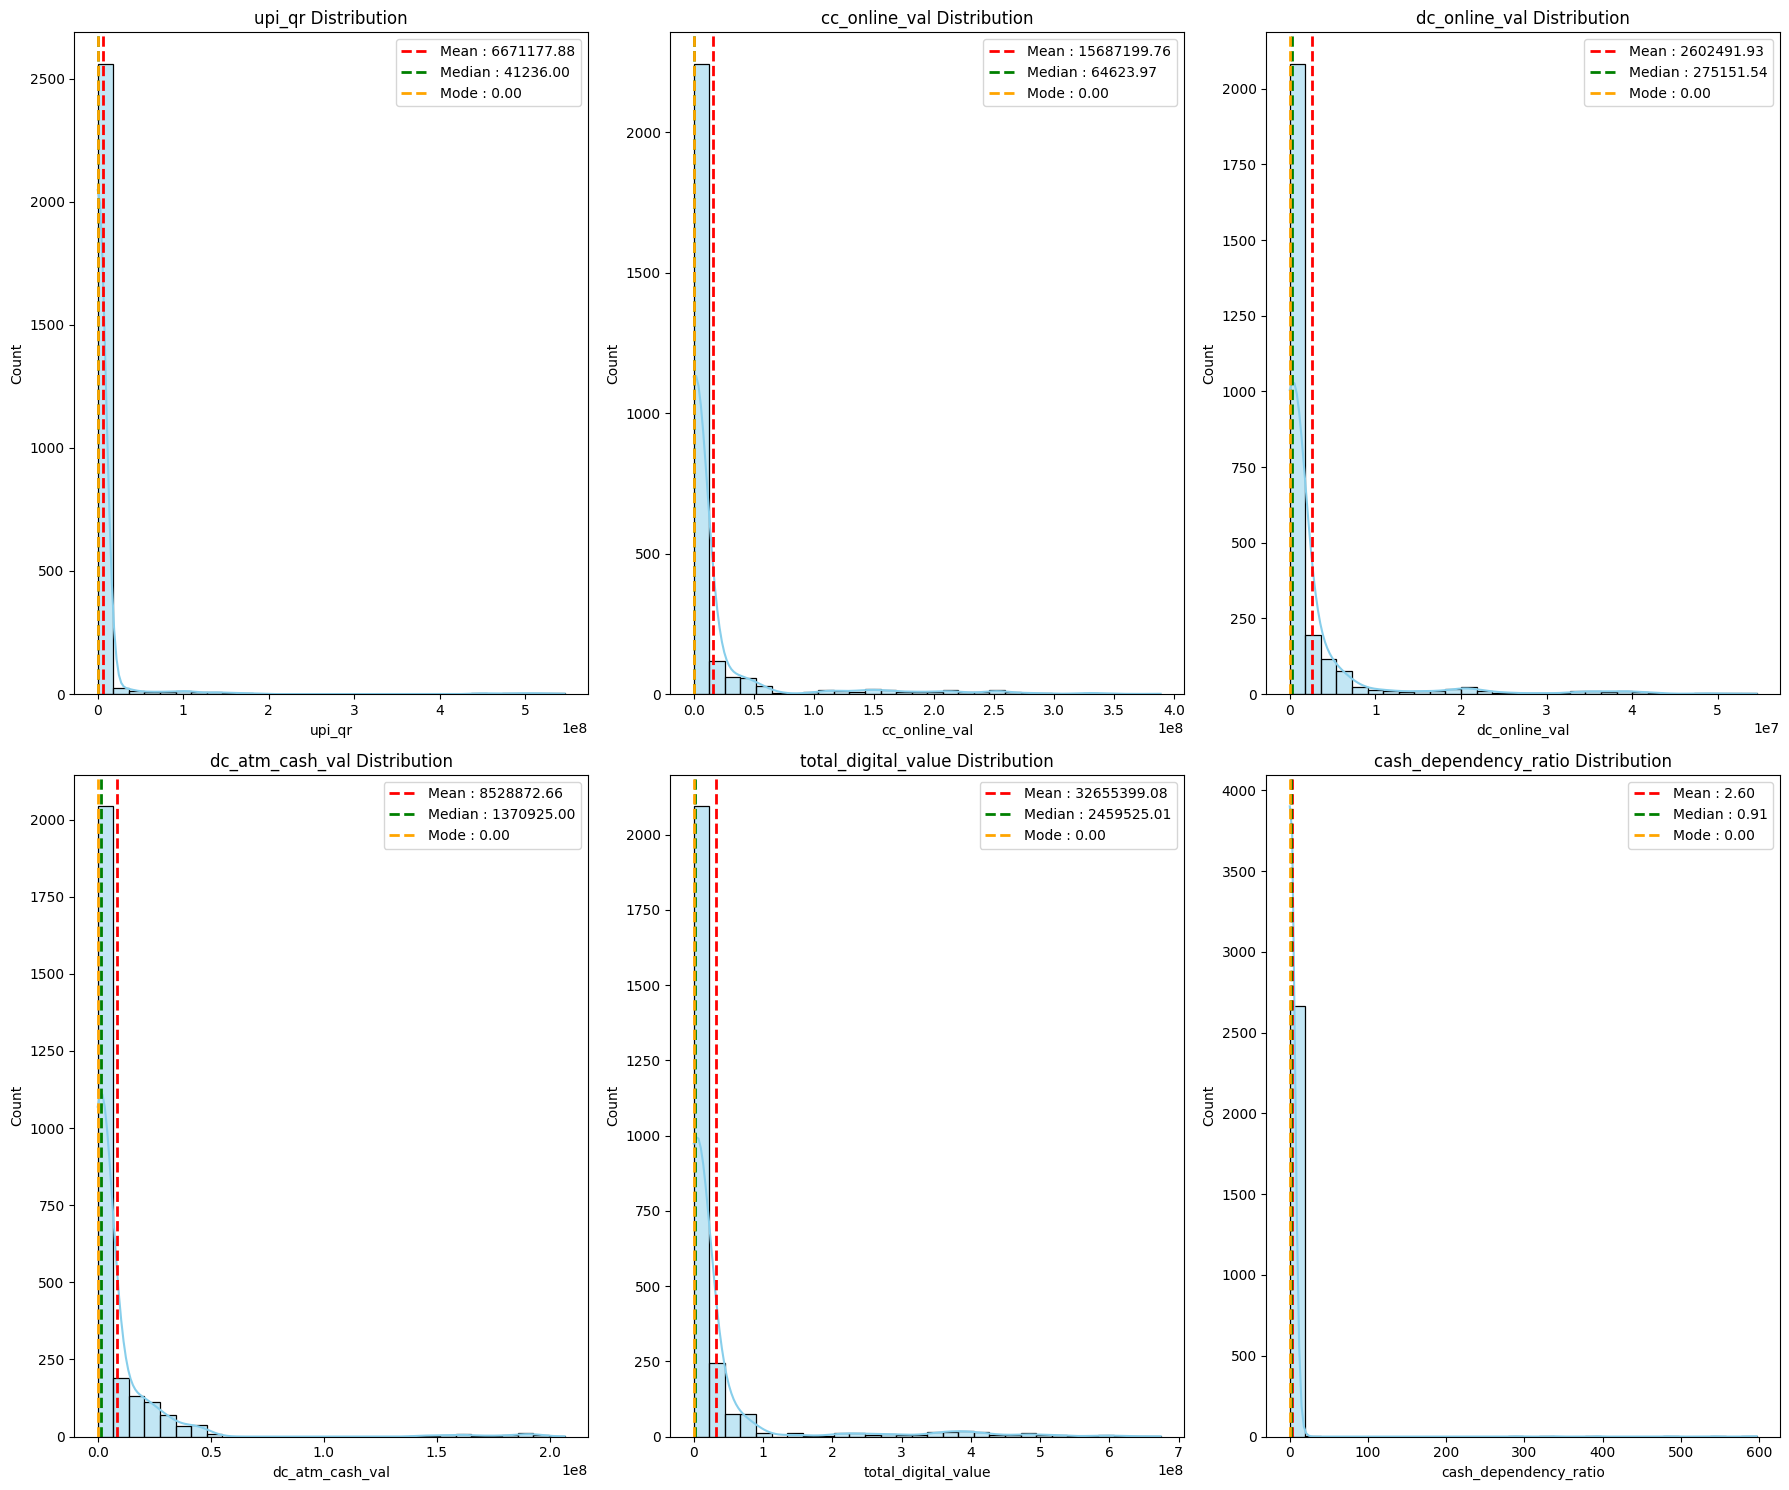

In [29]:
# Create 3x3 subplot layout

fig, axes = plt.subplots(2, 3, figsize=(18, 15))

axes = axes.flatten()

# Plot Histograms

for i, col in enumerate(cols):

    mean_val   = Summary_Table.loc[col, 'Mean']
    median_val = Summary_Table.loc[col, 'Median']
    mode_val   = Summary_Table.loc[col, 'Mode']

    sns.histplot(
        df[col],
        kde=True,
        bins=30,
        color='skyblue',
        ax=axes[i]
    )

    # Mean Line
    axes[i].axvline(
        mean_val,
        color='red',
        linestyle='--',
        linewidth=2,
        label=f'Mean : {mean_val:.2f}'
    )

    # Median Line
    axes[i].axvline(
        median_val,
        color='green',
        linestyle='--',
        linewidth=2,
        label=f'Median : {median_val:.2f}'
    )

    # Mode Line
    axes[i].axvline(
        mode_val,
        color='orange',
        linestyle='--',
        linewidth=2,
        label=f'Mode : {mode_val:.2f}'
    )

    axes[i].set_title(f'{col} Distribution')

    # Legend
    axes[i].legend(loc='upper right')

plt.tight_layout()

plt.show()

**1.c. Interpretation of Central Tendency Chart**

*1. Most banking transaction variables are highly positively skewed due to a few banks having extremely high transaction values.*

*2. Mean values are higher than median values in most columns, indicating the presence of high-value transaction outliers.*

*3. Mode values are mostly zero, showing that many banks have limited or no activity in certain transaction channels.*

*4. Digital transaction variables such as upi_qr, cc_online_val, and total_digital_value indicate that only a few banks dominate digital payment activity.*

*5. ATM cash withdrawal and cash dependency distributions show that while digital banking is increasing, some banks and customers still rely significantly on cash transactions.*

**2. Variance and Standard Deviation**

In [30]:
#2.a.Measure of Variance

Variance_Table = df[cols].var().to_frame(name='Variance')

print('Measure of Dispersion: Variance\n')
print(Variance_Table)

Measure of Dispersion: Variance

                           Variance
upi_qr                 1.894319e+15
cc_online_val          2.384974e+15
dc_online_val          4.892717e+13
dc_atm_cash_val        5.468354e+14
total_digital_value    8.562102e+15
cash_dependency_ratio  5.910667e+02


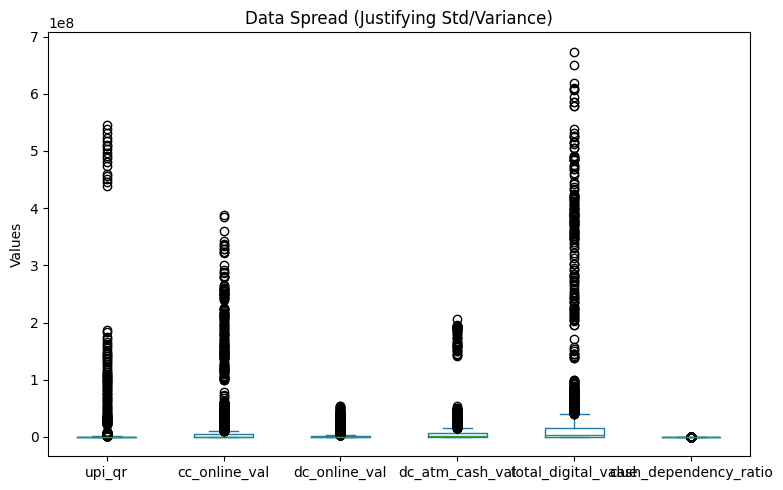

In [31]:
#2.b.Visualization of Variance

df[cols].plot(kind='box',figsize=(8,5))
plt.title('Data Spread (Justifying Std/Variance)')
plt.ylabel('Values')
plt.tight_layout()
plt.show()

In [32]:
#2.c. Measure of Standard Deviation

Std_Dev__Table = df[cols].std().to_frame(name='Std_Dev_Table')

print('Measure of Std_Dev: Std_Dev_Table\n')
print(Std_Dev__Table)

Measure of Std_Dev: Std_Dev_Table

                       Std_Dev_Table
upi_qr                  4.352378e+07
cc_online_val           4.883619e+07
dc_online_val           6.994796e+06
dc_atm_cash_val         2.338451e+07
total_digital_value     9.253163e+07
cash_dependency_ratio   2.431186e+01


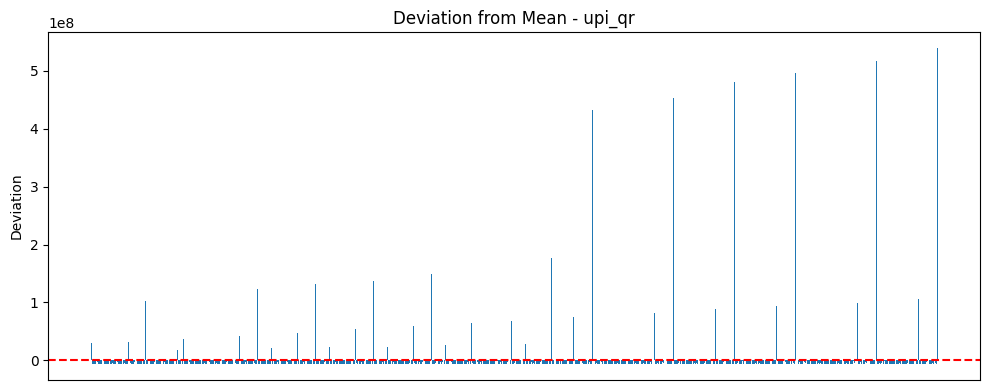

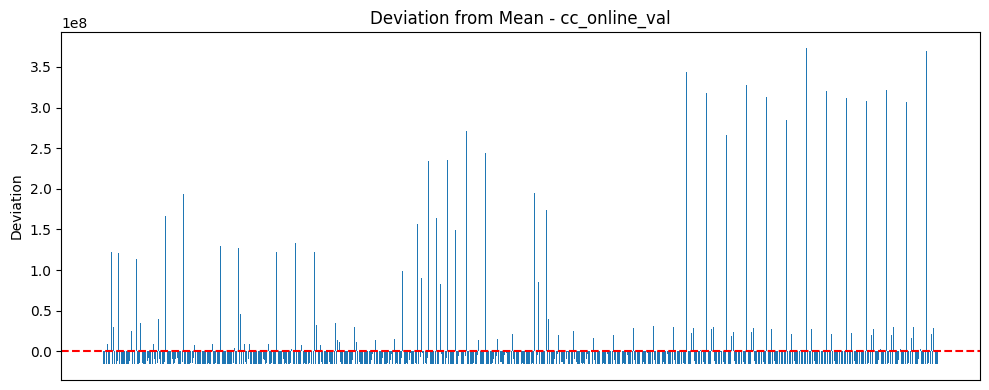

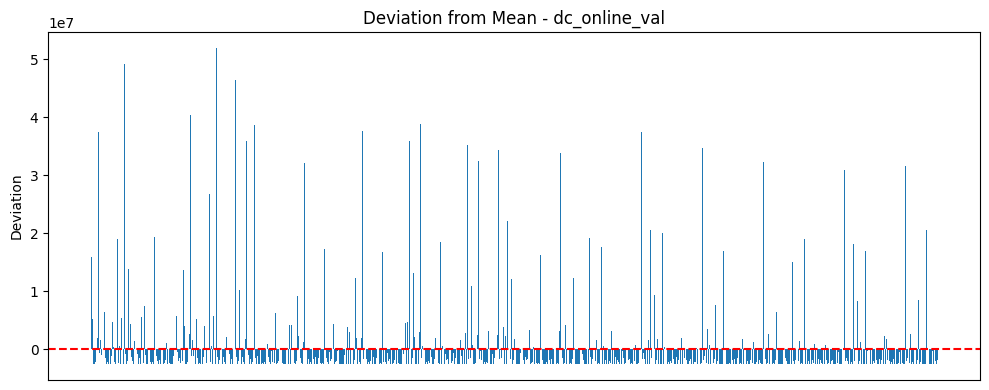

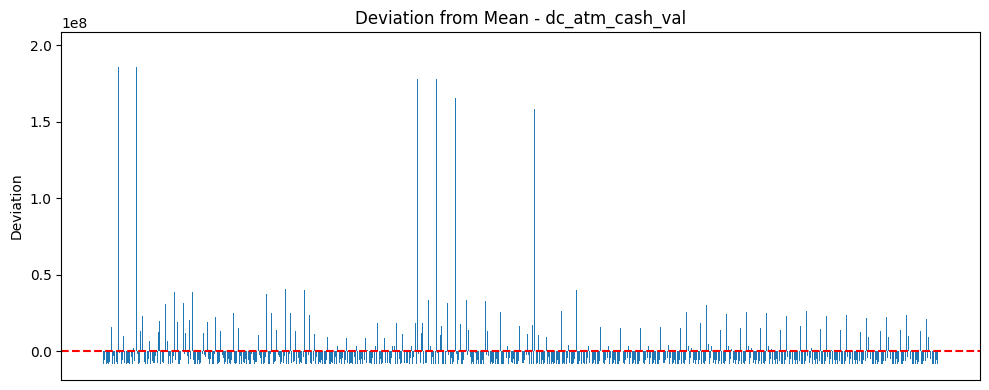

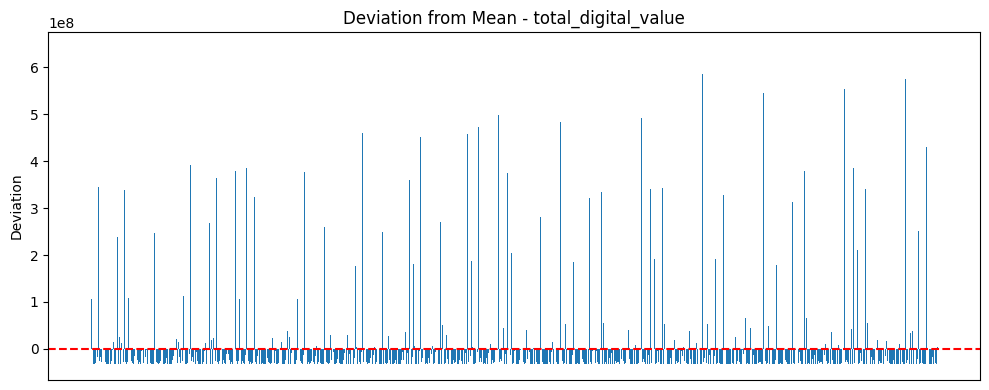

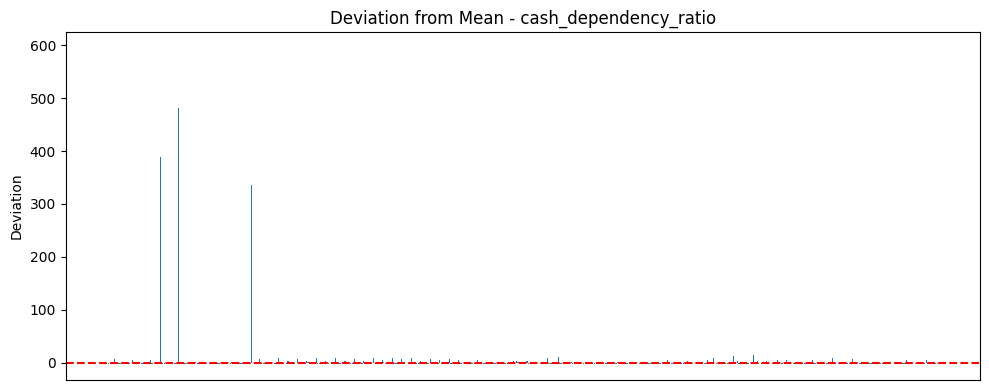

In [33]:
#2.d. Visualization of Standard Deviation

means = df[cols].mean()
deviation = df[cols] - means

for col in cols:
  plt.figure(figsize=(10,4))
  plt.bar(range(len(deviation)),deviation[col])
  plt.axhline(0,color='red',linestyle='--')
  plt.title(f'Deviation from Mean - {col}')
  plt.ylabel('Deviation')
  plt.xticks([])
  plt.tight_layout()
  plt.show()

**2.e. Interpretation of Variance and Standard Deviation Chart**

**1. The boxplot shows high variability in banking transaction data, indicating that transaction values differ significantly across banks and payment channels.*

*2. Variables such as upi_qr, cc_online_val, and total_digital_value contain large spreads and extreme outliers, showing that a few banks dominate digital transactions.*

*3. The standard deviation plots reveal that many observations are far from the mean, confirming the presence of highly fluctuating transaction behavior.*

*4. cash_dependency_ratio has comparatively lower spread for most banks, but a few extreme deviations indicate that some banks still rely heavily on cash transactions.*

*5. High variance and standard deviation across transaction variables indicate unequal digital adoption, customer activity, and transaction volume among different banking institutions.*

**3. Skewness and Kurtosis**

In [34]:
#3.a.Measure of Skewness

Skewness_Table=df[cols].skew().to_frame(name='Skewness')

print('Measure of Skewness: Skewness_Table\n')
print(Skewness_Table)

Measure of Skewness: Skewness_Table

                        Skewness
upi_qr                  9.872431
cc_online_val           4.219942
dc_online_val           4.244770
dc_atm_cash_val         5.973735
total_digital_value     3.975352
cash_dependency_ratio  20.818924


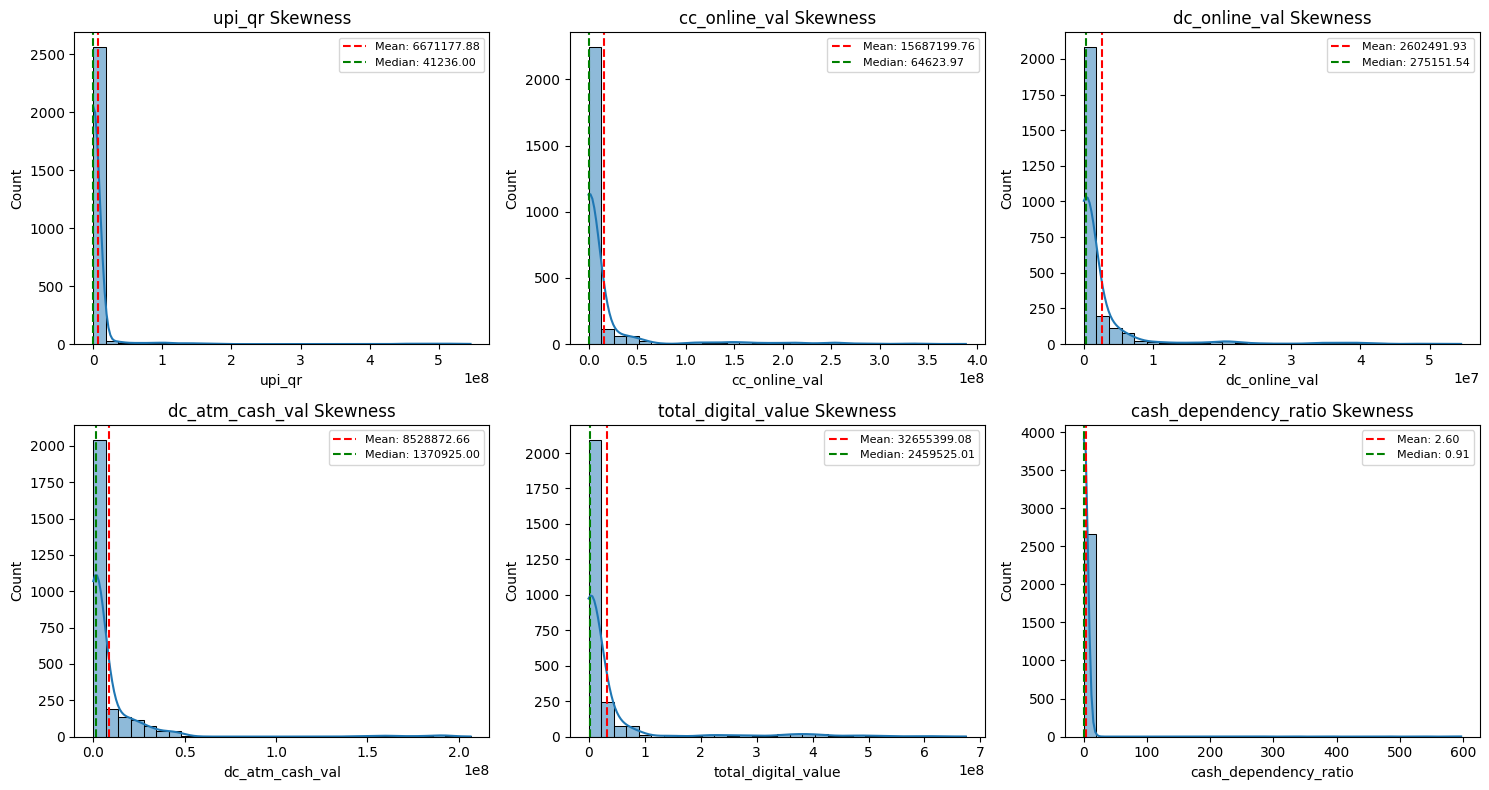

In [35]:
#3.b.Visualization of Skewness

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(cols):

    mean_val = df[col].mean()
    median_val = df[col].median()

    sns.histplot(df[col], kde=True, bins=30, ax=axes[i])

    # Mean & Median lines (used to interpret skewness)
    axes[i].axvline(mean_val, color='red', linestyle='--', label=f'Mean: {mean_val:.2f}')
    axes[i].axvline(median_val, color='green', linestyle='--', label=f'Median: {median_val:.2f}')

    axes[i].set_title(f"{col} Skewness")
    axes[i].legend(fontsize=8)

plt.tight_layout()
plt.show()

In [36]:
#3.c. Measure of Kurtosis

Kurtosis_Table=df[cols].kurt().to_frame(name='Kurtosis')

print('Measure of Kurtosis: Kurtosis_Table\n')
print(Kurtosis_Table)

Measure of Kurtosis: Kurtosis_Table

                         Kurtosis
upi_qr                 105.568169
cc_online_val           18.790892
dc_online_val           19.375127
dc_atm_cash_val         40.032811
total_digital_value     15.918621
cash_dependency_ratio  450.555318


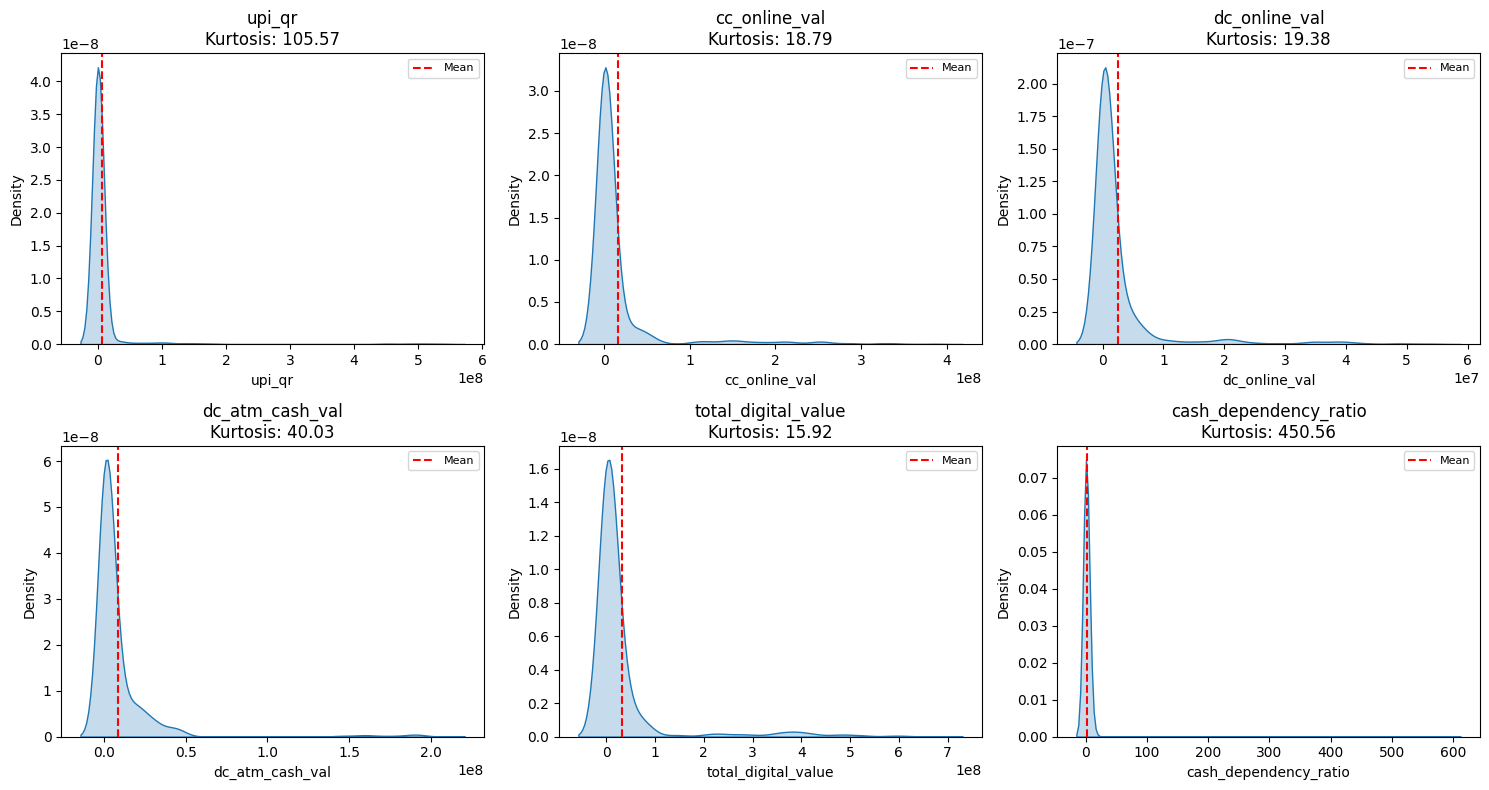

In [37]:
#3.d.Visualization of Kurtosis

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(cols):

    kurt_val = df[col].kurt()
    mean_val = df[col].mean()

    # KDE plot (no histogram)
    sns.kdeplot(df[col], fill=True, ax=axes[i])

    # Mean line
    axes[i].axvline(mean_val, color='red', linestyle='--', label='Mean')

    # Title with kurtosis value
    axes[i].set_title(f"{col}\nKurtosis: {kurt_val:.2f}")

    axes[i].legend(fontsize=8)

plt.tight_layout()
plt.show()

**3.e. Interpretation of Skewness and Kurtosis Chart**

*1. All variables are highly positively skewed because the mean is greater than the median, indicating the presence of extreme high-value banking transactions.*

*2. The skewed distributions show that only a few banks contribute heavily to digital transactions, ATM withdrawals, and overall transaction activity, while most banks operate at lower transaction levels.*

*3. Banking transaction variables show extreme concentration with rare high-value spikes this reflects realistic financial behavior where a small number of entities contribute disproportionately large transaction values.
cash_dependency_ratio and upi_qr exhibit the highest tail risk and variability.*

*4. Their extremely high kurtosis indicates occasional abnormal or exceptionally large observations, which may represent high-cash economies, seasonal spikes, or outlier business activity.*

*5. The dataset is naturally non-normal, which is common in financial systems. Heavy-tailed distributions are expected in banking and digital payments data.*

**4. Visualizations**

*4.a Univariate Analysis*

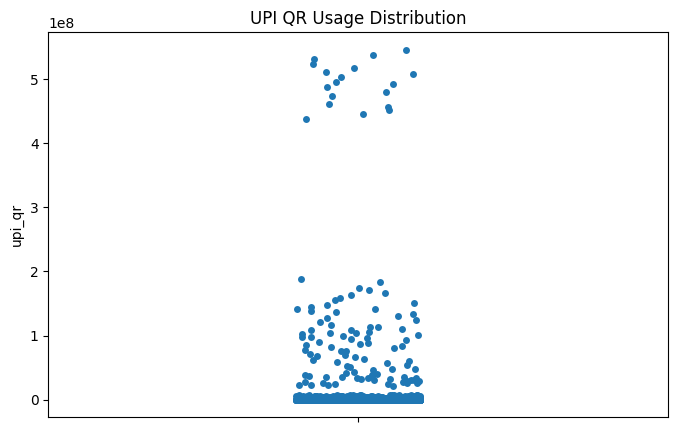

In [38]:
#1. UPI QR Distribution

plt.figure(figsize=(8,5))

sns.stripplot(
    y=df['upi_qr']
)

plt.title('UPI QR Usage Distribution')

plt.show()

*1. The strip plot shows that most UPI QR transaction values are concentrated near the lower range, indicating that a large number of observations have relatively small UPI QR usage values. The dense clustering of points at the bottom suggests frequent low-value QR-based digital transactions across the dataset.*

*2. At the same time, a few points extend up to nearly 550 million, showing the presence of significant outliers with extremely high UPI QR transaction values. This indicates that while most banks or users perform smaller QR transactions, a limited number contribute very large UPI QR transaction volumes.*

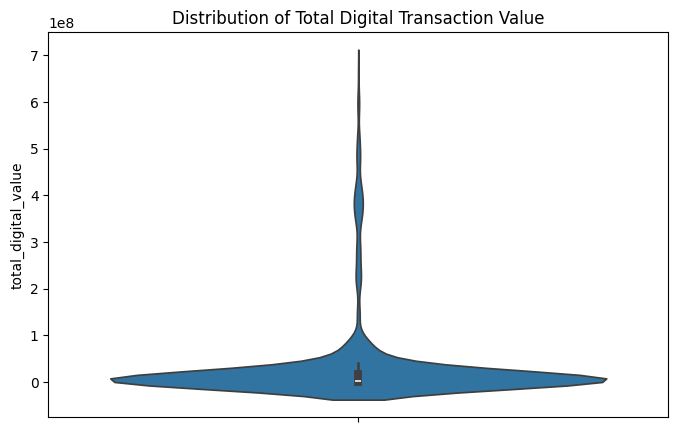

In [39]:
#2. Total Digital Transaction Value Distribution

plt.figure(figsize=(8,5))

sns.violinplot(
    y=df['total_digital_value']
)

plt.title('Distribution of Total Digital Transaction Value')

plt.show()

*1. The violin plot shows that the total digital transaction value is highly concentrated at the lower range, where most observations are clustered close to the bottom of the distribution. The wider lower portion of the violin indicates that a large number of banks or transactions have comparatively smaller digital transaction values.*

*2. At the same time, the long upper tail extending beyond 700 million indicates the presence of a few extremely high transaction values, showing strong positive skewness and potential outliers in the dataset. This suggests that while most digital transactions are moderate or low in value, a small number of banks contribute exceptionally large digital transaction volumes.*

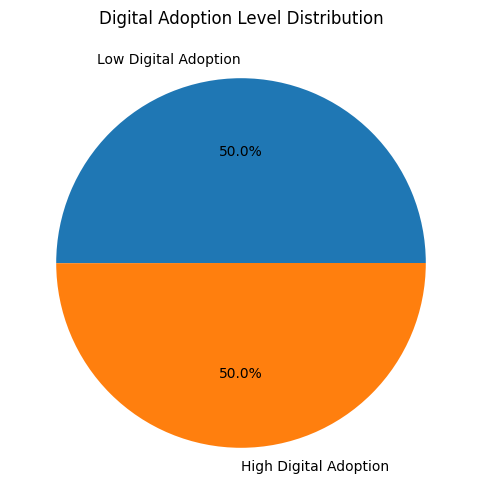

In [40]:
#3. Digital Adoption Level

digital_counts = df['digital_adoption_level'].value_counts()

plt.figure(figsize=(6,6))

plt.pie(
    digital_counts,
    labels=digital_counts.index,
    autopct='%1.1f%%'
)

plt.title('Digital Adoption Level Distribution')

plt.show()

*1. The pie chart shows that the dataset is evenly distributed between High and Low Digital Adoption Levels, with each category contributing approximately 50% of the total records. This indicates a balanced representation of banks with strong digital adoption and banks with lower digital adoption in the dataset.*

*2. The equal proportion suggests that the analysis does not favor one adoption level over the other, making it easier to compare transaction behavior, banking activity, and digital usage patterns between high and low digital adoption groups.*

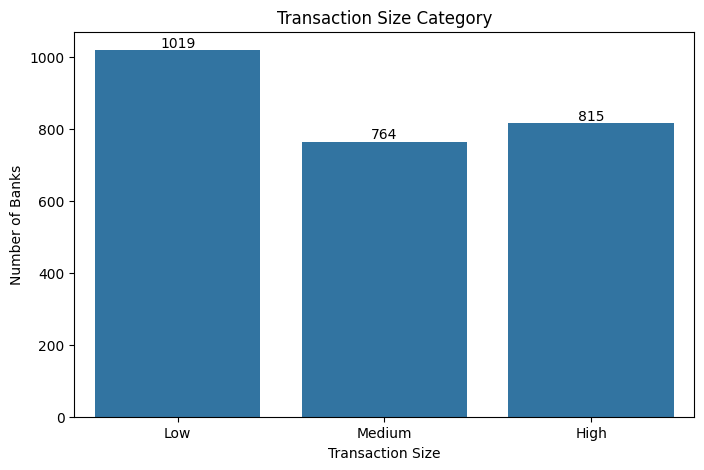

In [41]:
#4. Transaction Size Category Analysis

plt.figure(figsize=(8,5))

ax = sns.countplot(x='transaction_size', data=df)

# Add values on top of bars

for p in ax.patches:

    ax.annotate(
        f'{int(p.get_height())}',
        (p.get_x() + p.get_width()/2, p.get_height()),
        ha='center',
        va='bottom',
        fontsize=10
    )

plt.title('Transaction Size Category')

plt.xlabel('Transaction Size')

plt.ylabel('Number of Banks')

plt.show()

*The transaction size category analysis shows that most banks belong to the small transaction segment, indicating lower overall digital transaction activity for a large portion of banks. However, a considerable number of banks also fall under medium and high transaction categories, reflecting steady growth in digital banking adoption and transaction processing. The presence of 815 banks in the high transaction category highlights that several banks are significantly contributing to the overall digital transaction ecosystem.*

*4.b. Bivariate Analysis*

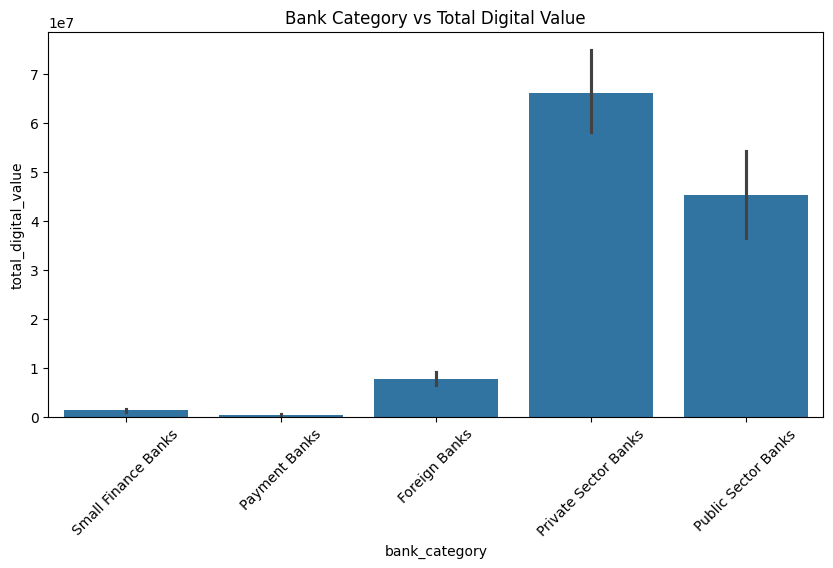

In [42]:
#1. Bank Category vs Total Digital Value

plt.figure(figsize=(10,5))

sns.barplot(
    x='bank_category',
    y='total_digital_value',
    data=df
)

plt.xticks(rotation=45)

plt.title('Bank Category vs Total Digital Value')

plt.show()

*The chart shows that Private Sector Banks generate the highest total digital transaction value, reaching nearly 66 million, followed by Public Sector Banks with around 45 million. In comparison, Foreign Banks, Small Finance Banks, and Payment Banks contribute significantly lower digital transaction values. This indicates that private and public sector banks dominate the digital banking ecosystem due to their larger customer base and stronger digital infrastructure.*

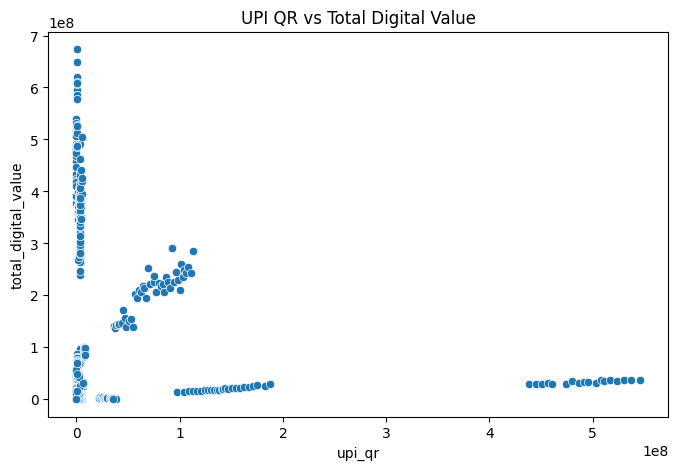

In [43]:
#2. UPI QR vs Total Digital Transaction Value

plt.figure(figsize=(8,5))

sns.scatterplot(
    x='upi_qr',
    y='total_digital_value',
    data=df
)

plt.title('UPI QR vs Total Digital Value')

plt.show()

*The scatter plot shows a positive relationship between UPI QR deployment and total digital transaction value, where banks with higher UPI QR counts generally achieve higher digital transaction volumes. Several banks with UPI QR values above 4 to 5 crore maintain digital transaction values around 3 to 4 crore, while a few banks with lower UPI QR deployment still generate very high transaction values nearing 6 to 7 crore. This indicates that although UPI adoption contributes significantly to digital transactions, other banking services and customer bases also influence total transaction performance.*

<Axes: xlabel='digital_adoption_level', ylabel='cash_dependency_ratio'>

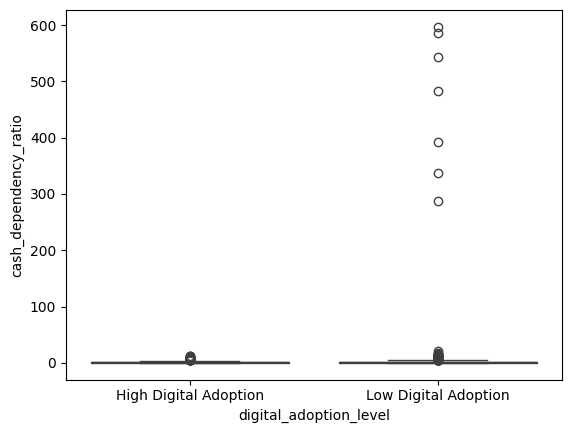

In [44]:
#3. Cash Dependency vs Digital Adoption

sns.boxplot(
    x='digital_adoption_level',
    y='cash_dependency_ratio',
    data=df
)

*The boxplot shows that banks with High Digital Adoption generally maintain very low cash dependency ratios, indicating stronger usage of digital payment systems over cash withdrawals. In contrast, banks with Low Digital Adoption exhibit several extreme cash dependency outliers, with ratios reaching nearly 600, showing that some banks still rely heavily on cash-based transactions. This suggests that increased digital adoption significantly reduces dependence on traditional cash withdrawal activities.*

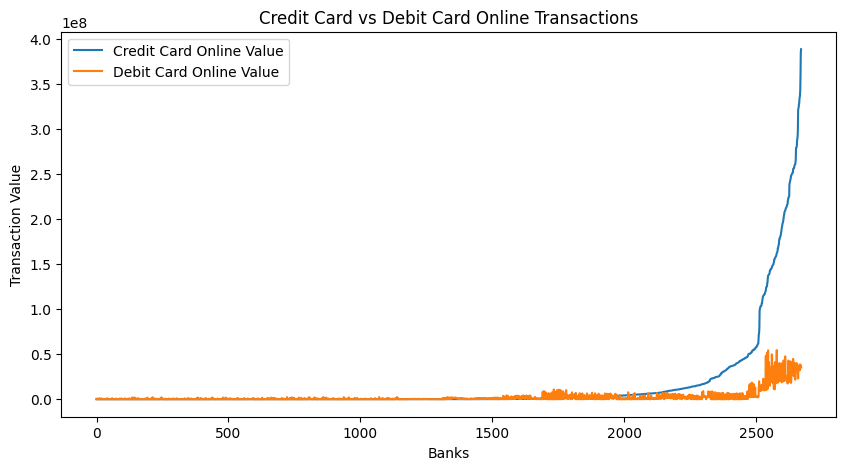

In [45]:
#4. Credit Card vs Debit Card Online Transactions

plt.figure(figsize=(10,5))

# Sort values for better visualization
sorted_df = df.sort_values(by='cc_online_val')

plt.plot(
    sorted_df['cc_online_val'].values,
    label='Credit Card Online Value'
)

plt.plot(
    sorted_df['dc_online_val'].values,
    label='Debit Card Online Value'
)

plt.title('Credit Card vs Debit Card Online Transactions')

plt.xlabel('Banks')

plt.ylabel('Transaction Value')

plt.legend()

plt.show()

*The line chart shows that credit card online transaction values increase sharply for a small group of banks, reaching nearly 390 million, while debit card online transaction values remain comparatively lower, peaking around 50 million. Most banks maintain relatively low transaction values for both payment channels, but a few banks dominate online card-based transactions. This indicates that credit card transactions contribute significantly higher transaction values in certain major banks compared to debit card transactions.*

**4.c. Multivariate Analysis**

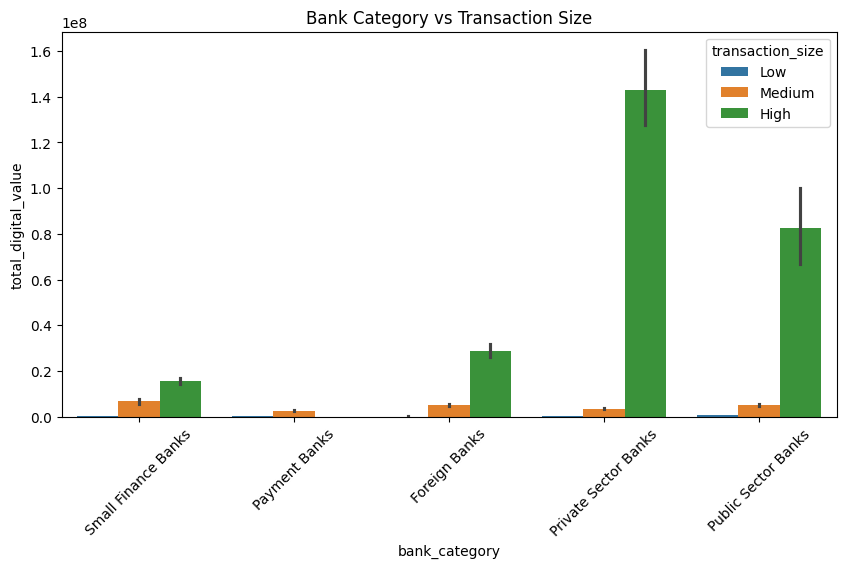

In [46]:
#1. Bank Category, Transaction Size & Digital Value

plt.figure(figsize=(10,5))

sns.barplot(
    x='bank_category',
    y='total_digital_value',
    hue='transaction_size',
    data=df
)

plt.xticks(rotation=45)

plt.title('Bank Category vs Transaction Size')

plt.show()

*1. The chart indicates that Private Sector Banks record the highest high-value digital transactions, reaching nearly 143 million, followed by Public Sector Banks at around 82 million. In contrast, Payment Banks show the lowest transaction values across all transaction sizes, highlighting their smaller contribution to total digital transaction volume.*

*2. Across all bank categories, the High transaction size segment dominates over Medium and Low categories, showing that larger-value digital transactions contribute the most to overall digital banking activity. Foreign Banks and Small Finance Banks also demonstrate moderate growth in high-value transactions compared to their lower transaction categories.*

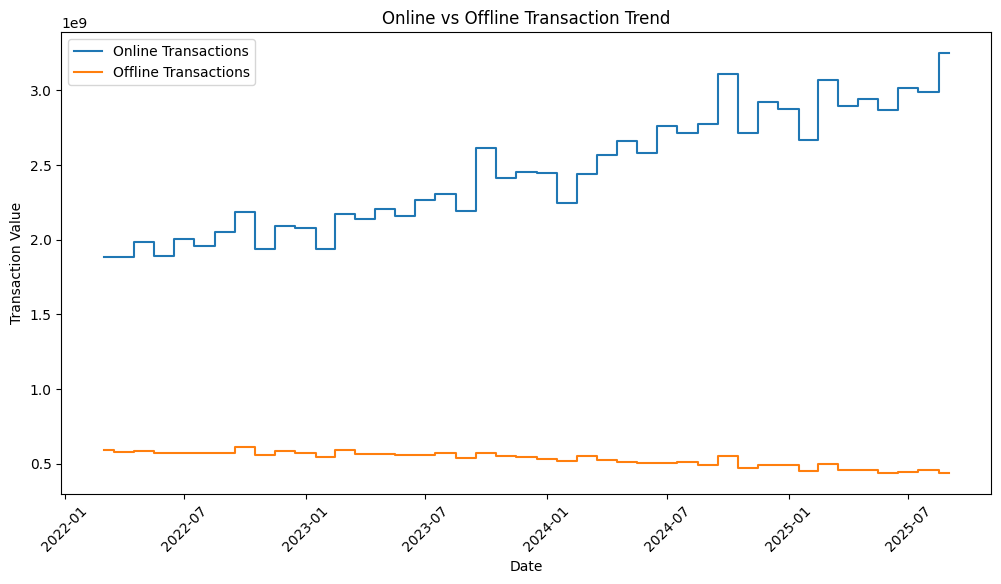

In [47]:
#2. Online vs Offline Transaction Trends Over Time

# Convert date column
df['date'] = pd.to_datetime(df['date'])

# Create Online and Offline totals
df['online_total'] = (
    df['upi_qr'] +
    df['bharat_qr'] +
    df['cc_online_val'] +
    df['dc_online_val'] +
    df['cc_pos_val'] +
    df['dc_pos_val']
)

df['offline_total'] = (
    df['cc_atm_cash_val'] +
    df['dc_atm_cash_val'] +
    df['dc_pos_cash_val']
)

# Group by date
trend = df.groupby('date')[['online_total', 'offline_total']].sum()

# Plot
plt.figure(figsize=(12,6))

plt.step(
    trend.index,
    trend['online_total'],
    where='mid',
    label='Online Transactions'
)

plt.step(
    trend.index,
    trend['offline_total'],
    where='mid',
    label='Offline Transactions'
)

plt.title('Online vs Offline Transaction Trend')
plt.xlabel('Date')
plt.ylabel('Transaction Value')

plt.legend()

plt.xticks(rotation=45)

plt.show()

*1. The chart shows a strong upward trend in online transactions from around 1.9 billion in early 2022 to approximately 3.25 billion by mid-2025, indicating rapid growth in digital payment adoption. Online transaction values crossed 3.0 billion several times during 2024–2025, highlighting increasing customer preference for online channels.*

*2. In contrast, offline transactions gradually declined from nearly 0.60 billion in 2022 to about 0.45 billion in 2025. While offline activity remained relatively stable with small fluctuations, the widening gap between online and offline transactions suggests a clear long-term shift toward digital and cashless transaction methods.*

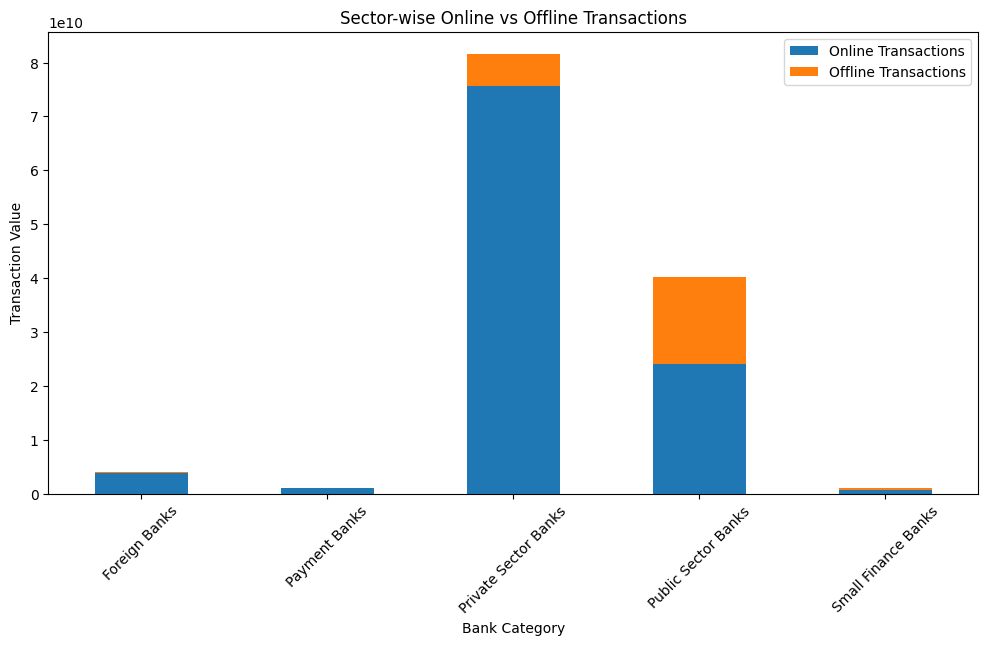

In [48]:
#3. Sector-wise Online vs Offline Transaction Analysis

# Create Online Total
df['online_total'] = (
    df['upi_qr'] +
    df['bharat_qr'] +
    df['cc_online_val'] +
    df['dc_online_val'] +
    df['cc_pos_val'] +
    df['dc_pos_val']
)

# Create Offline Total
df['offline_total'] = (
    df['cc_atm_cash_val'] +
    df['dc_atm_cash_val'] +
    df['dc_pos_cash_val']
)

# Group by Bank Category
sector_data = df.groupby('bank_category')[['online_total','offline_total']].sum()

# Plot Stacked Bar Chart
sector_data.plot(
    kind='bar',
    stacked=True,
    figsize=(12,6)
)

plt.title('Sector-wise Online vs Offline Transactions')
plt.xlabel('Bank Category')
plt.ylabel('Transaction Value')

plt.xticks(rotation=45)

plt.legend(['Online Transactions', 'Offline Transactions'])

plt.show()

*1. The chart highlights that Private Sector Banks dominate transaction activity, with online transactions reaching approximately 75 billion, compared to only about 6 billion offline transactions. Public Sector Banks follow with nearly 24 billion online and 16 billion offline transactions, showing a relatively stronger offline presence than private banks.*

*2. In comparison, Foreign Banks, Payment Banks, and Small Finance Banks contribute much smaller transaction volumes, each remaining below 5 billion overall. Across all banking sectors, online transactions consistently exceed offline transactions, indicating a widespread shift toward digital banking and electronic payment systems.*

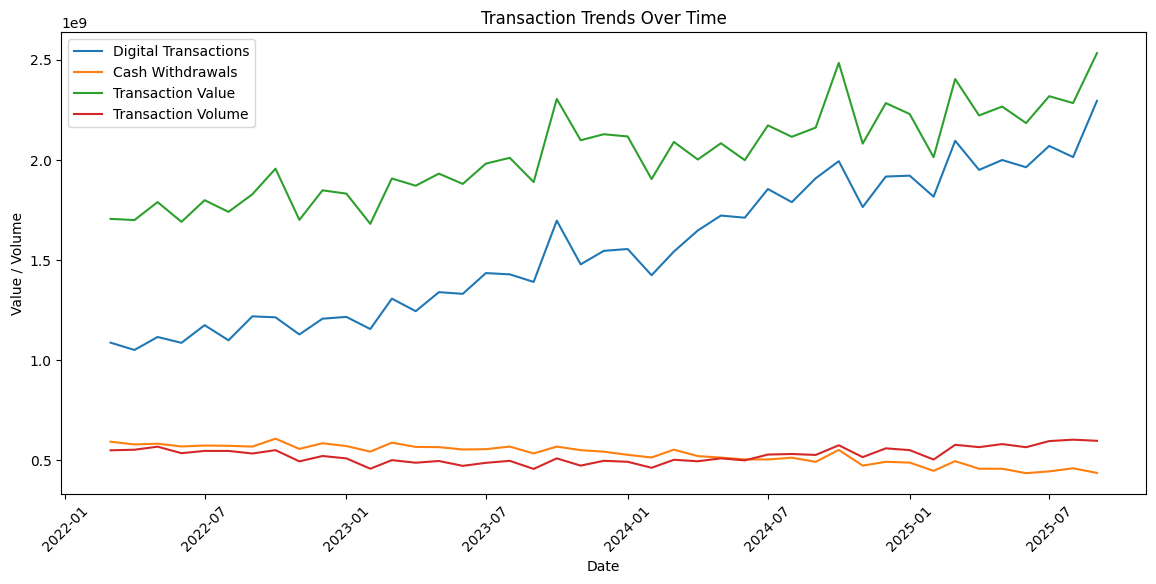

In [49]:
#4. Digital Transactions and Cash Withdrawal Trends Over Time

# Convert date column
df['date'] = pd.to_datetime(df['date'])

# Create Metrics

# Digital Transactions
df['digital_transactions'] = (
    df['upi_qr'] +
    df['bharat_qr'] +
    df['cc_online_val'] +
    df['dc_online_val']
)

# Cash Withdrawals
df['cash_withdrawals'] = (
    df['cc_atm_cash_val'] +
    df['dc_atm_cash_val']
)

# Transaction Value
df['transaction_value'] = (
    df['cc_online_val'] +
    df['dc_online_val'] +
    df['cc_pos_val'] +
    df['dc_pos_val']
)

# Transaction Volume
df['transaction_volume'] = (
    df['cc_online_vol'] +
    df['dc_online_vol'] +
    df['cc_pos_vol'] +
    df['dc_pos_vol']
)

# Group by Date
trend = df.groupby('date')[[
    'digital_transactions',
    'cash_withdrawals',
    'transaction_value',
    'transaction_volume'
]].sum()

# Plot
plt.figure(figsize=(14,6))

plt.plot(trend.index, trend['digital_transactions'], label='Digital Transactions')

plt.plot(trend.index, trend['cash_withdrawals'], label='Cash Withdrawals')

plt.plot(trend.index, trend['transaction_value'], label='Transaction Value')

plt.plot(trend.index, trend['transaction_volume'], label='Transaction Volume')

plt.title('Transaction Trends Over Time')

plt.xlabel('Date')
plt.ylabel('Value / Volume')

plt.legend()

plt.xticks(rotation=45)

plt.show()

*1. The chart shows a strong rise in digital transactions, increasing from around 1.1 billion in early 2022 to nearly 2.3 billion by mid-2025, reflecting rapid adoption of digital payment systems. Similarly, the overall transaction value grew from approximately 1.7 billion to over 2.5 billion, indicating higher monetary activity over time.*

*2. In contrast, cash withdrawals gradually declined from about 0.60 billion to nearly 0.45 billion, suggesting reduced dependence on cash-based transactions. Meanwhile, transaction volume remained relatively stable but showed a slight increase from around 0.55 billion to 0.60 billion, supporting the trend of growing digital financial engagement.*

# **# Stage 4 – Documentation, Insights & Presentation**

## **Summary**

The analysis of banking transaction data revealed a significant shift toward digital banking channels such as UPI, QR payments, credit cards, and debit cards. Most banks exhibited relatively lower transaction volumes, while a small number of banks contributed exceptionally high transaction values, creating a highly skewed transaction distribution. Private Sector Banks and Public Sector Banks emerged as the leading contributors to digital transaction value due to their extensive customer base and stronger digital infrastructure.

The study also showed that banks with higher digital adoption levels tend to have lower dependence on cash withdrawals. UPI QR deployment demonstrated a positive relationship with total digital transaction value, indicating that digital payment infrastructure plays a crucial role in transaction growth. Over time, online transactions increased substantially while cash withdrawals gradually declined, reflecting changing customer preferences toward digital payment methods.

---

## **Key Insights**

1. Private Sector Banks generated the highest digital transaction value, followed by Public Sector Banks, indicating stronger digital banking penetration.

2. Banks with high digital adoption levels showed significantly lower cash dependency ratios compared to banks with lower digital adoption.

3. UPI QR deployment positively influenced digital transaction performance, highlighting the importance of digital payment infrastructure.

4. Credit card online transactions contributed higher transaction values than debit card online transactions in several major banks.

5. Digital transactions increased consistently from 2022 to 2025, while cash withdrawals gradually decreased, indicating growing customer acceptance of digital banking services.

---

## **Types of Analysis**

### 1. Descriptive Analysis

Descriptive analysis was performed to understand banking transaction patterns and digital payment adoption. The results show that transaction values are highly skewed, with a few banks contributing exceptionally large transaction volumes. Significant variation exists across banks in terms of digital transactions and cash usage. UPI and online transaction channels are dominated by a small number of banks. Overall, the analysis highlights growing digital banking adoption along with differences in transaction behavior across banking institutions.

### 2. Diagnostic Analysis

Diagnostic analysis was conducted to identify factors influencing transaction behavior. The analysis revealed that banks with greater digital adoption and higher UPI QR deployment generally achieved larger digital transaction values. Comparisons across bank categories highlighted why Private and Public Sector Banks outperform smaller banking segments. The relationship between digital transactions and cash withdrawals also explained changes in customer payment preferences.

### 3. Predictive Analysis

Based on observed trends, digital transaction volumes are expected to continue increasing in the coming years. Banks with expanding UPI infrastructure, digital payment services, and online banking capabilities are likely to experience higher transaction growth. Cash dependency is expected to decrease further as customers increasingly adopt digital payment channels.

### 4. Prescriptive Analysis

Banks should continue investing in digital infrastructure, promote UPI and QR-based payment systems, and improve customer awareness of digital banking services. Institutions with lower digital adoption should strengthen their digital ecosystem to remain competitive. Strategic focus on online transaction channels can improve customer engagement and transaction growth.

---

## **Recommendations / Decision Support**

1. Expand UPI and QR-based payment infrastructure to increase digital transaction adoption.

2. Encourage customers to shift from cash-based transactions to digital payment channels through awareness programs and incentives.

3. Strengthen digital banking services in bank categories with lower transaction performance.

4. Monitor high-performing transaction channels such as credit card and online payment systems for further growth opportunities.

5. Use transaction size segmentation to identify high-value banking segments and develop targeted business strategies.

6. Continue reducing dependency on cash withdrawals by promoting secure and convenient digital alternatives.

---

## **Future Enhancements**

*1. Real-Time Banking Transaction Monitoring*

Integrate live banking and payment transaction feeds to monitor digital transaction trends and customer behavior in real time.

*2. Machine Learning-Based Transaction Forecasting*

Develop predictive models to forecast future digital transaction volumes, cash dependency levels, and digital adoption growth.

*3. Advanced Banking Performance Analytics*

Incorporate customer demographics, regional banking data, and branch-level information for deeper performance analysis and segmentation.

---

## **Conclusion**

This project analyzed banking transaction data to understand digital payment adoption, cash dependency, transaction behavior, and bank performance. The findings revealed that Private and Public Sector Banks play a major role in driving digital transactions, while UPI and online payment channels continue to grow rapidly. The analysis also showed that banks with higher digital adoption tend to have lower cash dependency, reflecting the ongoing shift toward digital banking. Although digital transactions dominate, some banks still exhibit significant reliance on cash-based services. Overall, the study highlights the increasing importance of digital payment systems and provides valuable insights to support data-driven decision-making in the banking sector.


